In [3]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 15.0 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy.stats import norm
import statsmodels.api as sm
from hmmlearn.hmm import GaussianHMM


In [5]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [159]:
df = pd.read_excel('индекс-мосбиржи-ru000a0jp7k5.xlsx')
df1 = pd.read_excel('индекс-мосбиржи-ru000a0jp7k5 (2).xlsx')
df2= pd.read_excel('индекс-мосбиржи-ru000a0jp7k5 (1).xlsx')
df3= pd.read_excel('индекс-мосбиржи-ru000a0jp7k5 (3).xlsx')

In [160]:
df_m = pd.concat([df,df1,df2,df3], axis= 0, ignore_index= True)
df_m = df_m.sort_values(by = 'Дата').reset_index(drop=True)



In [161]:
import pandas as pd
import numpy as np


vol_wind = 40

# 1. Переименовываем колонки
df_m = df_m.rename({
    'Индекс МосБиржи RU000A0JP7K5': 'Values',
    'Дата': 'Date'
}, axis=1)

# 2. Приводим дату к datetime
df_m['Date'] = pd.to_datetime(df_m['Date'], dayfirst=True, errors='coerce')

# 3. Приводим значения индекса к числовому формату
df_m['Values'] = (
    df_m['Values']
    .astype(str)
    .str.replace(' ', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df_m['Values'] = pd.to_numeric(df_m['Values'], errors='coerce')

# 4. Удаляем пропуски по дате и значению индекса
df_m = df_m.dropna(subset=['Date', 'Values']).copy()

# 5. Сортируем по дате
df_m = df_m.sort_values('Date').copy()

# 6. Делаем дату индексом
df_m = df_m.set_index('Date')

# 7. Задаем кризисные интервалы, которые исключаем из анализа
crisis_periods = [
    ('2020-02-20', '2020-04-09'),
    ('2022-02-16', '2022-04-04')
]

# 8. Создаем маску: True = оставить наблюдение, False = удалить
mask = pd.Series(True, index=df_m.index)

for start, end in crisis_periods:
    mask &= ~((df_m.index >= start) & (df_m.index <= end))

# 9. Удаляем выбранные кризисные интервалы
df_m_clean = df_m.loc[mask].copy()

# 10. Создаем номера непрерывных сегментов
# Если между соседними датами большой разрыв, это новый сегмент
# Это нужно, чтобы доходности и волатильность не считались через удаленные кризисные интервалы
df_m_clean['segment'] = (
    df_m_clean.index.to_series().diff().dt.days > 10
).cumsum()

# 11. Считаем логарифмические доходности внутри каждого сегмента
# Доходность НЕ считается через разрыв после удаления кризисных интервалов
df_m_clean['log_returns'] = (
    df_m_clean
    .groupby('segment')['Values']
    .transform(lambda x: np.log(x / x.shift(1)))
)

# 12. Удаляем первые NaN внутри каждого сегмента после расчета доходностей
df_m_clean = df_m_clean.dropna(subset=['log_returns']).copy()

# 13. Считаем 40-дневную rolling volatility внутри каждого сегмента
# Волатильность считается по исходным логарифмическим доходностям, без винзоризации
df_m_clean[f'volatility_{vol_wind}'] = (
    df_m_clean
    .groupby('segment')['log_returns']
    .rolling(vol_wind)
    .std()
    .reset_index(level=0, drop=True)
)

# 14. Удаляем NaN после расчета rolling volatility
df_m_clean = df_m_clean.dropna(subset=[f'volatility_{vol_wind}']).copy()

# 15. Проверяем результат
print("Период данных:")
print(df_m_clean.index.min(), "—", df_m_clean.index.max())

print("\nКоличество наблюдений после очистки:")
print(df_m_clean.shape)

print("\nПроверка удаленных кризисных периодов:")
for start, end in crisis_periods:
    print(
        start, "-", end,
        df_m_clean.loc[start:end].shape[0]
    )

print("\nПервые строки:")
display(df_m_clean.head())

print("\nПоследние строки:")
display(df_m_clean.tail())

Период данных:
2010-03-10 00:00:00 — 2026-05-15 00:00:00

Количество наблюдений после очистки:
(3863, 4)

Проверка удаленных кризисных периодов:
2020-02-20 - 2020-04-09 0
2022-02-16 - 2022-04-04 0

Первые строки:


,Values,segment,log_returns,volatility_40
Date,,,,
2010-03-10,1402.350000,0,-0.007247,0.014689
2010-03-11,1395.910000,0,-0.004603,0.014591
2010-03-12,1415.750000,0,0.014113,0.014749
2010-03-15,1400.190000,0,-0.011051,0.014649
2010-03-16,1420.760000,0,0.014584,0.014852



Последние строки:


,Values,segment,log_returns,volatility_40
Date,,,,
2026-05-11,2656.910000,4,0.022499,0.008311
2026-05-12,2689.960000,4,0.012363,0.008579
2026-05-13,2694.720000,4,0.001768,0.008592
2026-05-14,2658.840000,4,-0.013404,0.008700
2026-05-15,2633.840000,4,-0.009447,0.008779


In [162]:
df = df_m_clean

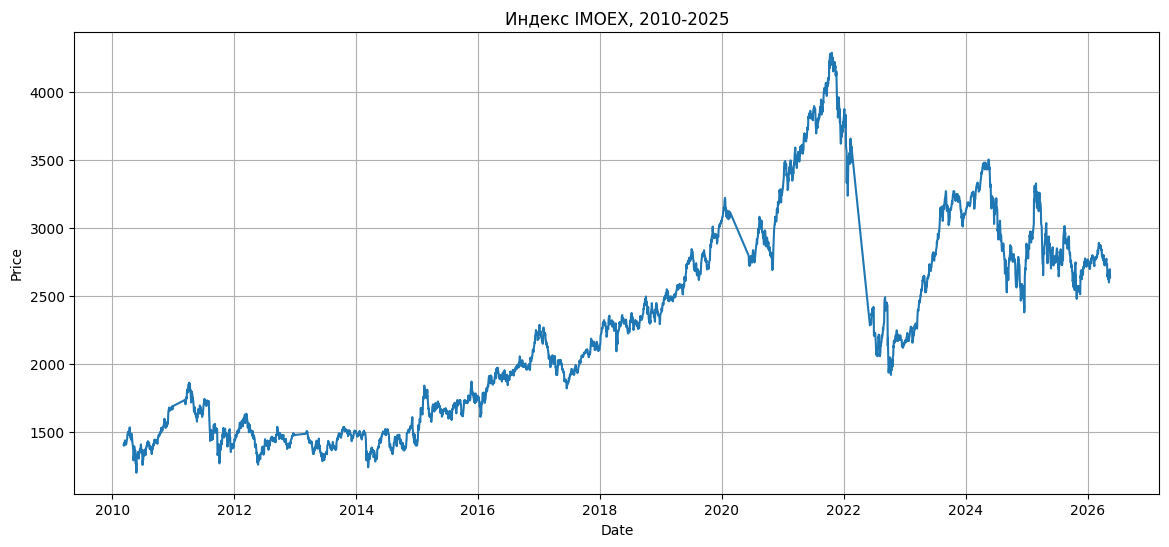

In [163]:
plt.figure(figsize = (14,6))

plt.plot( df['Values'])

plt.title('Индекс IMOEX, 2010-2025')
plt.xlabel('Date')
plt.ylabel('Price')

plt.grid(True)

plt.show()

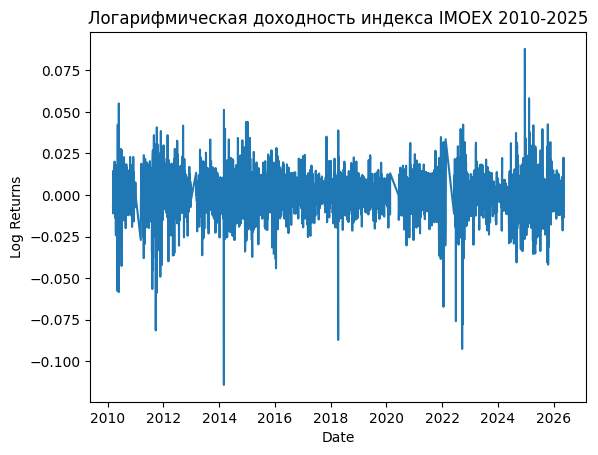

In [164]:
plt.Figure(figsize=(20,10))
plt.plot( df['log_returns'])

plt.title('Логарифмическая доходность индекса IMOEX 2010-2025')
plt.xlabel('Date')
plt.ylabel('Log Returns')

plt.show()


In [165]:

result = adfuller(df['log_returns'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')


ADF Statistic: -44.6891924450234
p-value: 0.0
Critical Value (1%): -3.4320448077976695
Critical Value (5%): -2.8622888731657667
Critical Value (10%): -2.567168634429352


Для подтверждения стационарности временного ряда логарифмических доходностей были использованы тесты ADF и KPSS. Результаты ADF-теста позволили отвергнуть гипотезу о наличии единичного корня (p-value < 0.01), тогда как KPSS-тест не позволил отвергнуть гипотезу стационарности (p-value > 0.1). Таким образом, оба теста подтверждают стационарность исследуемого ряда, что позволяет корректно применять скрытые марковские модели.

In [145]:
#Ljung–Box test Тесты на автокорреляцию

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(df['log_returns'], lags=[10, 20], return_df=True)
print(ljung)

     lb_stat  lb_pvalue
10 16.349497   0.090055
20 30.426930   0.063225


In [146]:
#ARCH-test Тесты на волатильность

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['log_returns'])

print('LM Statistic:', arch_test[0])
print('p-value:', arch_test[1])

LM Statistic: 218.36304820283374
p-value: 2.35238082465636e-41


In [147]:
# Jarque–Bera test Тесты на нормальность распределения

from scipy.stats import jarque_bera

jb_stat, jb_p = jarque_bera(df['log_returns'])

print('JB Statistic:', jb_stat)
print('p-value:', jb_p)

JB Statistic: 7666.182074620173
p-value: 0.0


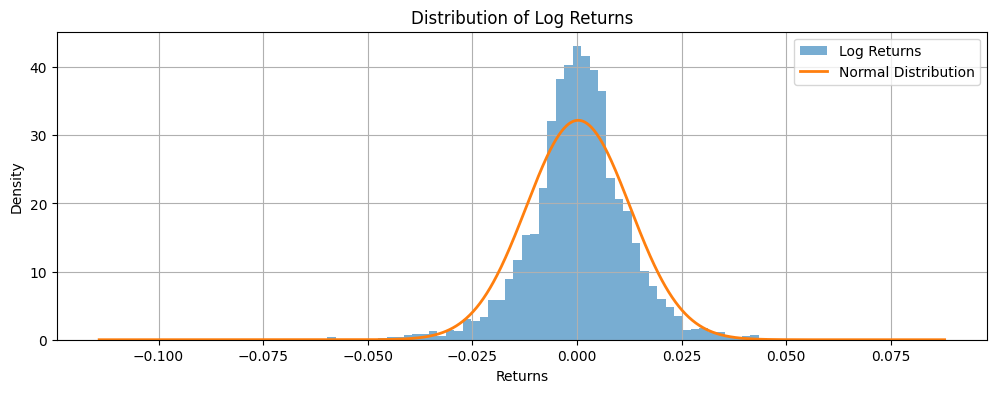

<Figure size 800x800 with 0 Axes>

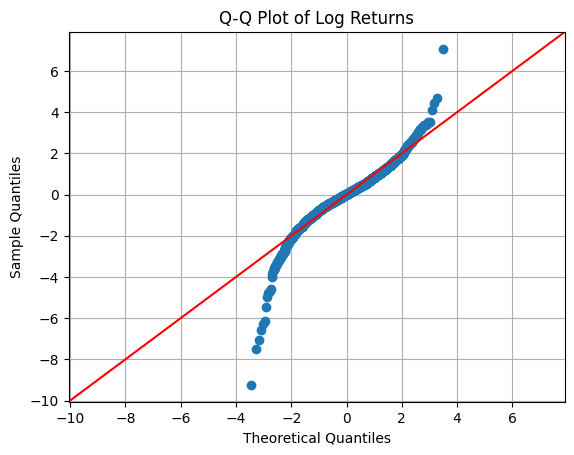

In [148]:
expect = df['log_returns'].mean()
sigma = df['log_returns'].std()

plt.figure(figsize=(12,4))

# histogram доходностей
plt.hist(
    df['log_returns'],
    bins=100,
    density=True,
    alpha=0.6,
    label='Log Returns'
)

# ось X
x = np.linspace(df['log_returns'].min(), df['log_returns'].max(), 1000)

# нормальное распределение
y = norm.pdf(x, expect, sigma)

# Gaussian curve
plt.plot(
    x,
    y,
    linewidth=2,
    label='Normal Distribution'
)

plt.title('Distribution of Log Returns')
plt.xlabel('Returns')
plt.ylabel('Density')

plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(8,8))

sm.qqplot(
    df['log_returns'].dropna(),
    line='45',
    fit=True
)

plt.title('Q-Q Plot of Log Returns')

plt.grid(True)
plt.show()

In [166]:
features = ['log_returns', f'volatility_{vol_wind}']

df_model = df.dropna(subset=features).copy()

num = int(len(df_model) * 0.8)

df_train = df_model.iloc[:num].copy()
df_test = df_model.iloc[num:].copy()

X_train = df_train[features].values
X_test = df_test[features].values

X_train = X_train * 100
X_test = X_test * 100

In [167]:
models = {}
results = []


for n_st in [2,3,4,5]:

  model = GaussianHMM(
      n_components = n_st, covariance_type = 'full', n_iter = 1000, random_state = 4
  )

  model.fit(X_train)

  train_loglik = model.score(X_train)
  test_loglik = model.score(X_test)

  models[n_st] = model



  results.append({'n_states': n_st,
        'train_loglik': train_loglik,
        'test_loglik': test_loglik,
        'train_loglik_per_obs': train_loglik / len(X_train),
        'test_loglik_per_obs': test_loglik / len(X_test)})

results_df = pd.DataFrame(results)

results_df

,n_states,train_loglik,test_loglik,train_loglik_per_obs,test_loglik_per_obs
0,2,-4696.124331,-1352.006186,-1.519781,-1.749038
1,3,-3452.680868,-1136.637102,-1.117372,-1.470423
2,4,-2755.882070,-967.292336,-0.891871,-1.251348
3,5,-2746.450486,-965.186557,-0.888819,-1.248624


In [168]:
def get_state_stats(model, X, df_part, return_col='log_returns'):
    states = model.predict(X)

    temp = df_part.copy()
    temp['state'] = states

    stats = temp.groupby('state')[return_col].agg(
        count='count',
        mean='mean',
        std='std',
        min='min',
        max='max'
    )

    stats_percent = stats.copy()
    for col in ['mean', 'std', 'min', 'max']:
        stats_percent[col] = stats_percent[col] * 100

    return stats_percent

In [169]:
stats_3 = get_state_stats(models[3], X_train, df_train)
stats_4 = get_state_stats(models[4], X_train, df_train)
stats_5 = get_state_stats(models[5], X_train, df_train)

print("HMM(3)")
display(stats_3)

print("HMM(4)")
display(stats_4)

print("HMM(5)")
display(stats_5)

HMM(3)


,count,mean,std,min,max
state,,,,,
0,854,-0.029734,1.811108,-11.418930,5.507022
1,1072,0.043209,1.070755,-3.987441,4.174836
2,1164,0.077326,0.784293,-2.990659,3.512529


HMM(4)


,count,mean,std,min,max
state,,,,,
0,1150,0.080379,0.781556,-2.990659,3.512529
1,398,-0.021525,2.161595,-11.418930,5.507022
2,516,-0.039009,1.410576,-5.652034,4.392175
3,1026,0.045998,1.063289,-3.643339,4.174836


HMM(5)


,count,mean,std,min,max
state,,,,,
0,556,0.058934,0.594175,-1.671440,1.730130
1,510,-0.037581,1.414909,-5.652034,4.392175
2,1030,0.052250,1.061097,-3.643339,4.174836
3,404,-0.023586,2.148755,-11.418930,5.507022
4,590,0.089906,0.927106,-2.990659,3.512529


In [195]:
best_n_states = 4
best_model = models[best_n_states]

df_train['state'] = best_model.predict(X_train)
df_test['state'] = best_model.predict(X_test)

# Добавляем вероятности принадлежности к каждому скрытому состоянию
train_probs = best_model.predict_proba(X_train)
test_probs = best_model.predict_proba(X_test)

for i in range(best_model.n_components):
    df_train[f'prob_state_{i}'] = train_probs[:, i]
    df_test[f'prob_state_{i}'] = test_probs[:, i]

state_names = {
    0: 'Low volatility',
    2: 'Moderate volatility',
    3: 'Stress regime',
    1: 'High volatility recovery'
}

df_train['state_name'] = df_train['state'].map(state_names)
df_test['state_name'] = df_test['state'].map(state_names)

In [196]:
state_stats_named = df_train.groupby('state_name')['log_returns'].agg(
    count='count',
    mean='mean',
    std='std',
    min='min',
    max='max'
)

state_stats_named_percent = state_stats_named.copy()

for col in ['mean', 'std', 'min', 'max']:
    state_stats_named_percent[col] = state_stats_named_percent[col] * 100

state_stats_named_percent

,count,mean,std,min,max
state_name,,,,,
High volatility recovery,398,-0.021525,2.161595,-11.418930,5.507022
Low volatility,1150,0.080379,0.781556,-2.990659,3.512529
Moderate volatility,516,-0.039009,1.410576,-5.652034,4.392175
Stress regime,1026,0.045998,1.063289,-3.643339,4.174836


In [197]:
transition_matrix = best_model.transmat_

transition_df = pd.DataFrame(
    transition_matrix,
    index=[f'From {state_names[i]}' for i in range(best_n_states)],
    columns=[f'To {state_names[i]}' for i in range(best_n_states)]
)

transition_df

,To Low volatility,To High volatility recovery,To Moderate volatility,To Stress regime
From Low volatility,0.989343,0.000876,0.000867,0.008915
From High volatility recovery,0.000000,0.982571,0.017429,0.000000
From Moderate volatility,0.000000,0.009565,0.966369,0.024066
From Stress regime,0.012005,0.001065,0.008146,0.978784


In [198]:
durations = {}

for i in range(best_n_states):
    p_ii = transition_matrix[i, i]
    durations[state_names[i]] = 1 / (1 - p_ii)

durations_df = pd.DataFrame.from_dict(
    durations,
    orient='index',
    columns=['Expected duration, trading days']
)

durations_df

,"Expected duration, trading days"
Low volatility,93.831653
High volatility recovery,57.375780
Moderate volatility,29.734417
Stress regime,47.134319


In [199]:
from scipy.stats import multivariate_normal
import numpy as np

# Оцениваем параметры обычной Gaussian-модели на train
mu = X_train.mean(axis=0)
cov = np.cov(X_train.T)

# Если один признак, np.cov может вернуть число, приведем к матрице
if X_train.shape[1] == 1:
    cov = np.array([[cov]])

# Log-likelihood на train и test для обычной Gaussian-модели
gaussian_train_loglik = multivariate_normal.logpdf(
    X_train,
    mean=mu,
    cov=cov,
    allow_singular=True
).sum()

gaussian_test_loglik = multivariate_normal.logpdf(
    X_test,
    mean=mu,
    cov=cov,
    allow_singular=True
).sum()

comparison = pd.DataFrame({
    'Model': ['Gaussian baseline', 'HMM(4)'],
    'Train loglik per obs': [
        gaussian_train_loglik / len(X_train),
        best_model.score(X_train) / len(X_train)
    ],
    'Test loglik per obs': [
        gaussian_test_loglik / len(X_test),
        best_model.score(X_test) / len(X_test)
    ]
})

comparison

,Model,Train loglik per obs,Test loglik per obs
0,Gaussian baseline,-2.298190,-2.277564
1,HMM(4),-0.891871,-1.251348


In [200]:
df_test['state'] = best_model.predict(X_test)
df_test['state_name'] = df_test['state'].map(state_names)

test_state_stats = df_test.groupby('state_name')['log_returns'].agg(
    count='count',
    mean='mean',
    std='std',
    min='min',
    max='max'
)

test_state_stats_percent = test_state_stats.copy()

for col in ['mean', 'std', 'min', 'max']:
    test_state_stats_percent[col] = test_state_stats_percent[col] * 100

test_state_stats_percent

,count,mean,std,min,max
state_name,,,,,
High volatility recovery,102,0.214357,1.922107,-3.547462,8.788073
Low volatility,331,0.055619,0.742933,-2.905941,2.249886
Moderate volatility,252,-0.121866,1.442316,-4.181557,4.255163
Stress regime,88,-0.085436,1.037563,-2.822895,3.120447


In [201]:
transition_matrix = best_model.transmat_

transition_df = pd.DataFrame(
    transition_matrix,
    index=[f'From {state_names[i]}' for i in range(best_n_states)],
    columns=[f'To {state_names[i]}' for i in range(best_n_states)]
)

transition_df.round(6)

,To Low volatility,To High volatility recovery,To Moderate volatility,To Stress regime
From Low volatility,0.989343,0.000876,0.000867,0.008915
From High volatility recovery,0.000000,0.982571,0.017429,0.000000
From Moderate volatility,0.000000,0.009565,0.966369,0.024066
From Stress regime,0.012005,0.001065,0.008146,0.978784


In [202]:
df_hmm = pd.concat([df_train, df_test]).sort_index()

In [203]:
def forecast_next_day_regimes_with_risk(df_hmm, model, state_names, date=None):
    """
    Прогноз вероятностей режимов на следующий торговый день
    + агрегированная вероятность высокой волатильности.
    """

    import pandas as pd
    import numpy as np

    if date is None:
        date = df_hmm.index.max()
    else:
        date = pd.to_datetime(date)

    if date not in df_hmm.index:
        raise ValueError(f"Дата {date.date()} отсутствует в df_hmm")

    prob_cols = [f'prob_state_{i}' for i in range(model.n_components)]

    current_probs = df_hmm.loc[date, prob_cols].values.astype(float)
    next_probs = current_probs @ model.transmat_

    current_state = int(np.argmax(current_probs))
    next_state = int(np.argmax(next_probs))

    forecast_table = pd.DataFrame({
        'state': list(range(model.n_components)),
        'regime': [state_names[i] for i in range(model.n_components)],
        'current_probability_%': current_probs * 100,
        'next_day_probability_%': next_probs * 100
    })

    forecast_table = forecast_table.sort_values(
        'next_day_probability_%',
        ascending=False
    ).reset_index(drop=True)

    high_vol_regimes = ['Stress regime', 'High volatility recovery']

    high_vol_states = [
        state for state, name in state_names.items()
        if name in high_vol_regimes
    ]

    prob_next_high_volatility = next_probs[high_vol_states].sum() * 100

    summary = pd.DataFrame({
        'date': [date],
        'current_regime': [state_names[current_state]],
        'current_regime_probability_%': [current_probs[current_state] * 100],
        'most_likely_next_day_regime': [state_names[next_state]],
        'most_likely_next_day_probability_%': [next_probs[next_state] * 100],
        'prob_next_high_volatility_%': [prob_next_high_volatility]
    })

    return summary, forecast_table

In [204]:
summary, forecast_table = forecast_next_day_regimes_with_risk(
    df_hmm=df_hmm,
    model=best_model,
    state_names=state_names
)

display(summary)
display(forecast_table)

,date,current_regime,current_regime_probability_%,most_likely_next_day_regime,most_likely_next_day_probability_%,prob_next_high_volatility_%
0,2026-05-15,Low volatility,99.573292,Low volatility,98.517223,1.393009


,state,regime,current_probability_%,next_day_probability_%
0,0,Low volatility,99.573292,98.517223
1,3,Stress regime,0.426689,1.305353
2,2,Moderate volatility,0.000011,0.089768
3,1,High volatility recovery,0.000009,0.087655


In [205]:


# Колонки с вероятностями текущих состояний
prob_cols = [f'prob_state_{i}' for i in range(best_model.n_components)]

# Текущие вероятности состояний
current_probs = df_hmm[prob_cols].values

# Прогноз вероятностей состояний на следующий торговый день
next_probs = current_probs @ best_model.transmat_

# Прогнозируемое состояние завтра
df_hmm['pred_next_state'] = np.argmax(next_probs, axis=1)
df_hmm['pred_next_state_name'] = df_hmm['pred_next_state'].map(state_names)

# Фактическое состояние следующего торгового дня
df_hmm['actual_next_state'] = df_hmm['state'].shift(-1)
df_hmm['actual_next_state_name'] = df_hmm['state_name'].shift(-1)

# Убираем последнюю строку, где нет следующего дня
eval_regime = df_hmm.dropna(subset=['actual_next_state']).copy()
eval_regime['actual_next_state'] = eval_regime['actual_next_state'].astype(int)

# Accuracy
regime_accuracy = (
    eval_regime['pred_next_state'] == eval_regime['actual_next_state']
).mean()

# Самый частый режим в данных
most_common_state = eval_regime['state'].mode()[0]

baseline_accuracy = (
    eval_regime['actual_next_state'] == most_common_state
).mean()

print(f"One-step-ahead HMM regime accuracy: {regime_accuracy:.2%}")
print(f"Baseline accuracy: {baseline_accuracy:.2%}")

One-step-ahead HMM regime accuracy: 97.70%
Baseline accuracy: 38.35%


In [206]:
# Самый частый режим в данных


In [207]:
state_stats = df_hmm.groupby('state')['log_returns'].agg(
    count='count',
    mean='mean',
    std='std'
)

state_stats_percent = state_stats.copy()
state_stats_percent[['mean', 'std']] *= 100

state_stats_percent.sort_values('std')

,count,mean,std
state,,,
0,1481,0.074845,0.772913
3,1114,0.035616,1.061414
2,768,-0.066196,1.420662
1,500,0.026595,2.115238


In [208]:
high_vol_states = (
    state_stats
    .sort_values('std', ascending=False)
    .head(2)
    .index
    .tolist()
)

high_vol_states

[1, 2]

In [209]:
prob_cols = [f'prob_state_{i}' for i in range(best_model.n_components)]

current_probs = df_hmm[prob_cols].values
next_probs = current_probs @ best_model.transmat_

df_hmm['prob_next_high_volatility_fixed'] = next_probs[:, high_vol_states].sum(axis=1)

In [210]:
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np

# если вероятность вдруг в процентах, переводим обратно в доли
prob = df_hmm['prob_next_high_volatility_fixed'].copy()

if prob.max() > 1:
    prob = prob

# на всякий случай ограничим диапазон [0, 1]
prob = prob.clip(0, 1)

df_hmm['prob_next_high_volatility_fixed_clean'] = prob

threshold = df_hmm['log_returns'].abs().quantile(0.75)

df_hmm['abs_return_tomorrow'] = df_hmm['log_returns'].shift(-1).abs()

df_hmm['high_vol_tomorrow'] = (
    df_hmm['abs_return_tomorrow'] > threshold
).astype(int)

eval_vol = df_hmm.dropna(subset=[
    'prob_next_high_volatility_fixed_clean',
    'high_vol_tomorrow',
    'abs_return_tomorrow'
]).copy()

auc = roc_auc_score(
    eval_vol['high_vol_tomorrow'],
    eval_vol['prob_next_high_volatility_fixed_clean']
)

brier_hmm = brier_score_loss(
    eval_vol['high_vol_tomorrow'],
    eval_vol['prob_next_high_volatility_fixed_clean']
)

baseline_prob = eval_vol['high_vol_tomorrow'].mean()

brier_baseline = brier_score_loss(
    eval_vol['high_vol_tomorrow'],
    np.repeat(baseline_prob, len(eval_vol))
)

print(f"ROC-AUC: {auc:.3f}")
print(f"Brier score HMM: {brier_hmm:.4f}")
print(f"Brier score baseline: {brier_baseline:.4f}")
print(f"Baseline probability: {baseline_prob:.2%}")

ROC-AUC: 0.686
Brier score HMM: 0.3052
Brier score baseline: 0.1876
Baseline probability: 25.01%


In [211]:
eval_vol['prob_group'] = pd.qcut(
    eval_vol['prob_next_high_volatility_fixed'],
    q=5,
    duplicates='drop'
)

calibration_table = eval_vol.groupby('prob_group').agg(
    count=('high_vol_tomorrow', 'count'),
    avg_predicted_prob=('prob_next_high_volatility_fixed', 'mean'),
    actual_high_vol_frequency=('high_vol_tomorrow', 'mean'),
    avg_abs_return_tomorrow=('abs_return_tomorrow', 'mean')
)

calibration_table['avg_predicted_prob_%'] = calibration_table['avg_predicted_prob'] * 100
calibration_table['actual_high_vol_frequency_%'] = calibration_table['actual_high_vol_frequency'] * 100
calibration_table['avg_abs_return_tomorrow_%'] = calibration_table['avg_abs_return_tomorrow'] * 100

calibration_table[
    [
        'count',
        'avg_predicted_prob_%',
        'actual_high_vol_frequency_%',
        'avg_abs_return_tomorrow_%'
    ]
].round(3)

/tmp/ipykernel_939/2327440014.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration_table = eval_vol.groupby('prob_group').agg(


,count,avg_predicted_prob_%,actual_high_vol_frequency_%,avg_abs_return_tomorrow_%
prob_group,,,,
"(0.00174117, 0.00174218]",773,0.174000,9.702000,0.572000
"(0.00174218, 0.00875328]",772,0.238000,15.415000,0.684000
"(0.00875328, 0.0092412]",772,0.920000,23.705000,0.805000
"(0.0092412, 0.975934]",772,63.292000,34.456000,1.048000
"(0.975934, 1.0]",773,99.161000,41.785000,1.293000


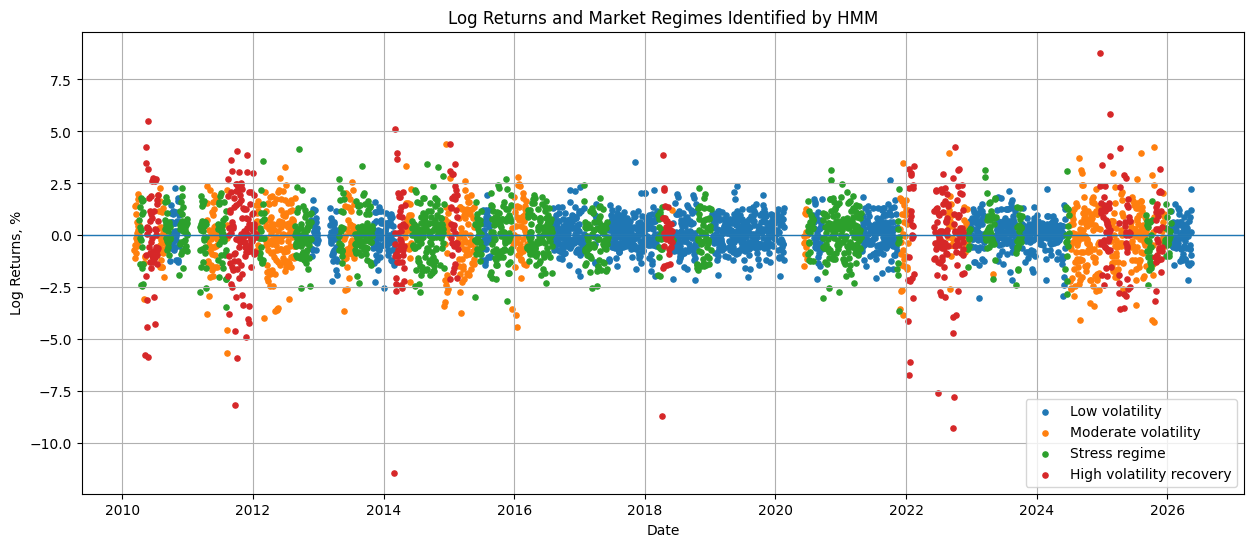

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

for state, name in state_names.items():
    subset = df_hmm[df_hmm['state'] == state]

    plt.scatter(
        subset.index,
        subset['log_returns'] * 100,
        s=14,
        label=name
    )

plt.axhline(0, linewidth=1)

plt.title('Log Returns and Market Regimes Identified by HMM')
plt.xlabel('Date')
plt.ylabel('Log Returns, %')
plt.grid(True)
plt.legend()

plt.show()

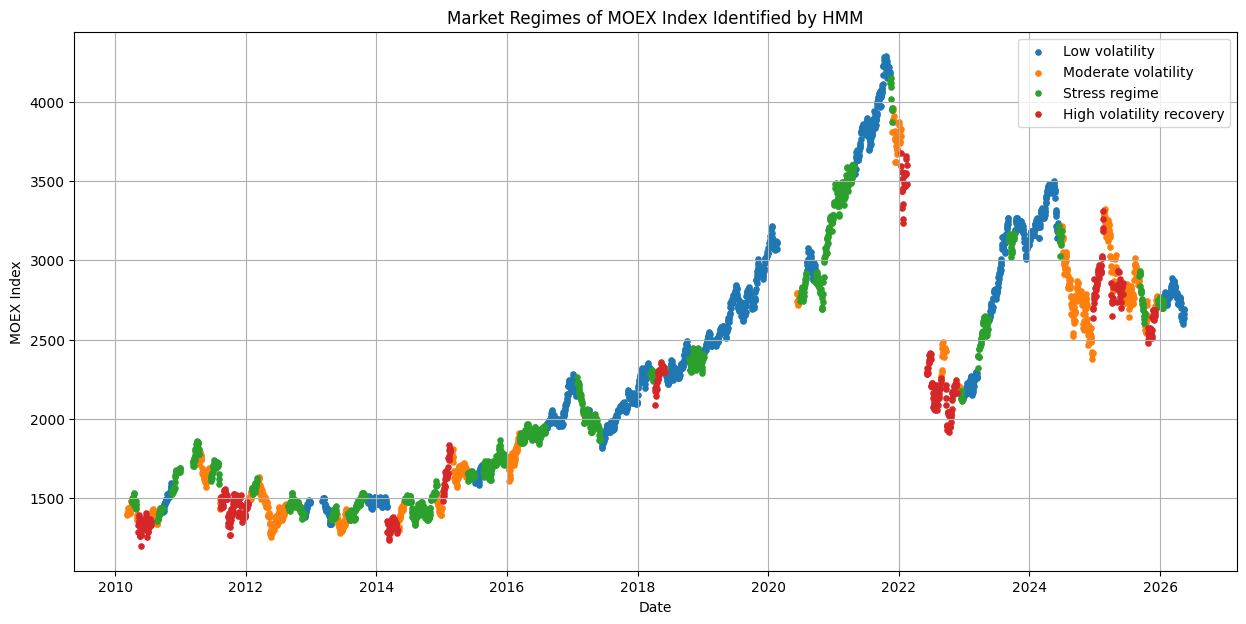

In [213]:
plt.figure(figsize=(15, 7))

for state, name in state_names.items():
    subset = df_hmm[df_hmm['state'] == state]

    plt.scatter(
        subset.index,
        subset['Values'],
        s=14,
        label=name
    )

plt.title('Market Regimes of MOEX Index Identified by HMM')
plt.xlabel('Date')
plt.ylabel('MOEX Index')
plt.grid(True)
plt.legend()

plt.show()

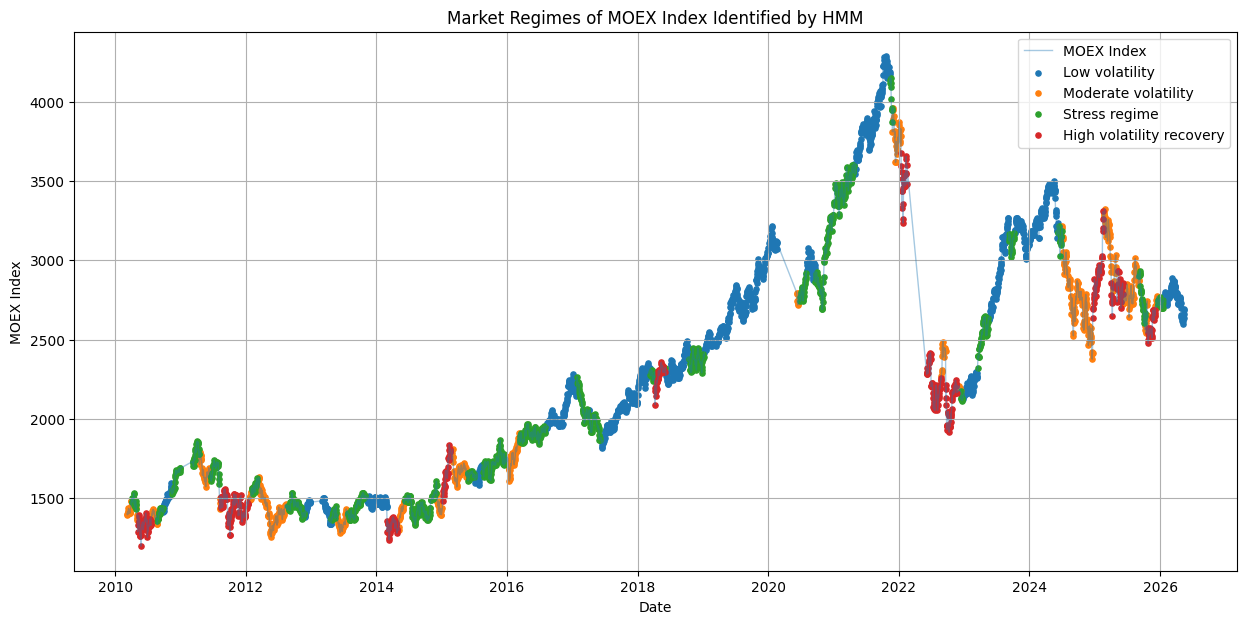

In [214]:
colors = {
    'Low volatility': 'tab:blue',
    'Moderate volatility': 'tab:orange',
    'Stress regime': 'tab:green',
    'High volatility recovery': 'tab:red'
}

plt.figure(figsize=(15, 7))

# линия индекса серым фоном
plt.plot(
    df_hmm.index,
    df_hmm['Values'],
    linewidth=1,
    alpha=0.4,
    label='MOEX Index'
)

# точки режимов
for state, name in state_names.items():
    subset = df_hmm[df_hmm['state'] == state]

    plt.scatter(
        subset.index,
        subset['Values'],
        s=14,
        label=name,
        color=colors[name]
    )

plt.title('Market Regimes of MOEX Index Identified by HMM')
plt.xlabel('Date')
plt.ylabel('MOEX Index')
plt.grid(True)
plt.legend()

plt.show()